# CSI motion detection on `wifi_data_set_fixed`

In [ ]:
from pathlib import Path
import os
import re
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "tools" / "csi_parser.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from tools.wifi_data_preprocess import PreprocessConfig, motion_energy, preprocess_amplitude, robust_zscore
from tools.csi_parser import Parser

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["image.aspect"] = "auto"
np.set_printoptions(suppress=True, linewidth=120)

DATASET_ROOT = PROJECT_ROOT / "wifi_data_set_fixed"
if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Не найден DATASET_ROOT={DATASET_ROOT}")

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATASET_ROOT =", DATASET_ROOT)

ModuleNotFoundError: No module named 'wifi_data_preprocess'

## Experiment Settings

In [16]:
DEVICE_ORDER = ("dev1", "dev2", "dev3")

# label_00 -> no motion; label_01..03 -> motion at distance 1..3 m.
NO_MOTION_LABEL = "label_00"
MOTION_LABELS = ("label_01", "label_02", "label_03")
LABEL_TO_DISTANCE_M = {
    "label_00": 0,
    "label_01": 1,
    "label_02": 2,
    "label_03": 3,
}

PREPROCESS_CONFIG = PreprocessConfig(
    pipeline="hampel_savgol",  # "none", "median", "hampel_savgol"
    apply_detrend=False,
    apply_zscore=False,
    hampel_window=7,
    hampel_sigma=3.0,
    sg_window=11,
    sg_poly=3,
    median_window=7,
    detrend_window=51,
    scale_floor_percentile=10.0,
    z_clip=8.0,
)

# Every fixed recording currently has 100 packets per receiver.
ML_WINDOW = 100
ML_STEP = 100

# Balance binary classes by default: all no-motion recordings and the same number
# of motion recordings sampled round-robin from label_01/02/03.
BALANCE_BINARY_CLASSES = True
ML_MAX_RECORDINGS_PER_BINARY_CLASS = None

# "motion_only" is the most honest starting point for movement detection.
# Use "all" for diagnostics or "absolute_only" to see how much baseline leakage helps.
FEATURE_SET = "motion_only"  # "motion_only", "absolute_only", "all"

# "recording_id" prevents windows from the same test folder from leaking across split.
# "person" is stricter and estimates generalization to unseen people, but only has 4 groups.
SPLIT_GROUP = "recording_id"  # "recording_id" or "person"
RANDOM_STATE = 42

print(PREPROCESS_CONFIG)

PreprocessConfig(pipeline='hampel_savgol', apply_detrend=False, apply_zscore=False, hampel_window=7, hampel_sigma=3.0, sg_window=11, sg_poly=3, median_window=7, detrend_window=51, scale_floor_percentile=10.0, z_clip=8.0)


## Dataset Index

Одна строка индекса соответствует папке `test_*`, то есть одной записи с тремя приёмниками.

In [17]:
DEVICE_RE = re.compile(r"__(dev\d+)_")
TEST_RE = re.compile(r"test_(\d+)$")


def natural_test_key(path: Path) -> tuple[int, str]:
    match = TEST_RE.search(path.name)
    return (int(match.group(1)) if match else 10**9, path.name)


def device_name_from_path(path: Path) -> str:
    match = DEVICE_RE.search(path.name)
    if not match:
        raise ValueError(f"Cannot infer device name from {path.name}")
    return match.group(1)


def build_recording_index(dataset_root: Path = DATASET_ROOT) -> pd.DataFrame:
    rows = []

    for person_dir in sorted(dataset_root.glob("id_person_*")):
        if not person_dir.is_dir():
            continue
        for label_dir in sorted(person_dir.glob("label_*")):
            if not label_dir.is_dir():
                continue
            for test_dir in sorted(label_dir.glob("test_*"), key=natural_test_key):
                if not test_dir.is_dir():
                    continue

                files_by_device = {}
                for path in sorted(test_dir.glob("*.data")):
                    files_by_device[device_name_from_path(path)] = path

                missing = [dev for dev in DEVICE_ORDER if dev not in files_by_device]
                label_name = label_dir.name
                distance_m = LABEL_TO_DISTANCE_M.get(label_name)
                binary_label = 0 if label_name == NO_MOTION_LABEL else 1

                row = {
                    "recording_id": str(test_dir.relative_to(dataset_root)),
                    "person": person_dir.name,
                    "source_label": label_name,
                    "binary_label": binary_label,
                    "binary_name": "no_motion" if binary_label == 0 else "motion",
                    "distance_m": distance_m,
                    "test": test_dir.name,
                    "test_dir": test_dir,
                    "n_devices": len(files_by_device),
                    "missing_devices": ",".join(missing),
                }
                for dev in DEVICE_ORDER:
                    row[f"{dev}_path"] = files_by_device.get(dev)
                rows.append(row)

    index = pd.DataFrame(rows)
    if index.empty:
        raise ValueError(f"No recordings found in {dataset_root}")
    return index


recordings_df = build_recording_index()

print("Recordings:", len(recordings_df))
print("Files:", int(recordings_df["n_devices"].sum()))
print("Missing device rows:", int((recordings_df["missing_devices"] != "").sum()))
print("\nBy person/label:")
display(recordings_df.groupby(["person", "source_label"]).size().unstack(fill_value=0))
print("\nBinary balance:")
display(recordings_df["binary_name"].value_counts())
recordings_df.head()

Recordings: 1600
Files: 4800
Missing device rows: 0

By person/label:


source_label,label_00,label_01,label_02,label_03
person,,,,
id_person_01,100,100,100,100
id_person_02,100,100,100,100
id_person_03,100,100,100,100
id_person_04,100,100,100,100



Binary balance:


binary_name
motion       1200
no_motion     400
Name: count, dtype: int64

,recording_id,person,source_label,binary_label,binary_name,distance_m,test,test_dir,n_devices,missing_devices,dev1_path,dev2_path,dev3_path
0,id_person_01/label_00/test_01,id_person_01,label_00,0,no_motion,0,test_01,/home/LijnxArcher/CSI-activity-detection/wifi_...,3,,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...
1,id_person_01/label_00/test_02,id_person_01,label_00,0,no_motion,0,test_02,/home/LijnxArcher/CSI-activity-detection/wifi_...,3,,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...
2,id_person_01/label_00/test_03,id_person_01,label_00,0,no_motion,0,test_03,/home/LijnxArcher/CSI-activity-detection/wifi_...,3,,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...
3,id_person_01/label_00/test_04,id_person_01,label_00,0,no_motion,0,test_04,/home/LijnxArcher/CSI-activity-detection/wifi_...,3,,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...
4,id_person_01/label_00/test_05,id_person_01,label_00,0,no_motion,0,test_05,/home/LijnxArcher/CSI-activity-detection/wifi_...,3,,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...,/home/LijnxArcher/CSI-activity-detection/wifi_...


## CSI Parser And Null Subcarriers

Новый датасет содержит 128 raw IQ-значений на packet. `tools.csi_parser.Parser` переводит их в 64 комплексные поднесущие и amplitude. Постоянно нулевые amplitude-поднесущие выводятся из данных автоматически.

In [18]:
def parse_amplitude_file(path: Path) -> tuple[np.ndarray, pd.DataFrame]:
    """Parse one fixed ESP32-S3 file using tools.csi_parser.Parser."""

    df = Parser(path).parse()
    amplitude = np.stack(df["amplitude"].to_numpy()).astype(np.float32)
    return amplitude, df


def infer_null_subcarriers(
    recordings: pd.DataFrame,
    sample_per_label: int = 4,
    zero_ratio_threshold: float = 0.99,
) -> list[int]:
    """Infer subcarrier indexes that are zero in almost every sampled packet."""

    sample_rows = []
    for label, group in recordings.groupby("source_label", sort=True):
        sample_rows.append(group.head(sample_per_label))
    sample = pd.concat(sample_rows, ignore_index=True)

    zero_counts = None
    total_packets = 0
    subcarrier_count = None

    for _, row in sample.iterrows():
        for dev in DEVICE_ORDER:
            amplitude, _ = parse_amplitude_file(row[f"{dev}_path"])
            if subcarrier_count is None:
                subcarrier_count = amplitude.shape[1]
            elif amplitude.shape[1] != subcarrier_count:
                raise ValueError("Inconsistent subcarrier count while inferring null subcarriers")

            zeros = np.isclose(amplitude, 0.0).sum(axis=0)
            zero_counts = zeros if zero_counts is None else zero_counts + zeros
            total_packets += amplitude.shape[0]

    zero_ratio = zero_counts / max(total_packets, 1)
    null_idx = np.flatnonzero(zero_ratio >= zero_ratio_threshold).astype(int).tolist()
    return null_idx


NULL_SUBCARRIERS = infer_null_subcarriers(recordings_df)
VALID_SUBCARRIERS = [i for i in range(64) if i not in NULL_SUBCARRIERS]

print("NULL_SUBCARRIERS =", NULL_SUBCARRIERS)
print("Valid subcarriers:", len(VALID_SUBCARRIERS), "of 64")

NULL_SUBCARRIERS = [0, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
Valid subcarriers: 52 of 64


In [19]:
def remove_null_subcarriers(amplitude: np.ndarray, null_subcarriers: list[int] | tuple[int, ...]) -> np.ndarray:
    if not null_subcarriers:
        return np.asarray(amplitude, dtype=np.float32)
    return np.delete(np.asarray(amplitude, dtype=np.float32), null_subcarriers, axis=-1)


def load_recording(row: pd.Series, null_subcarriers: list[int] | tuple[int, ...] = NULL_SUBCARRIERS) -> dict:
    """Load one test folder as [T, D, S] amplitude plus aligned RSSI metadata."""

    amplitudes = []
    rssi_values = []
    packet_seq_values = []
    local_timestamp_values = []

    for dev in DEVICE_ORDER:
        amplitude, df = parse_amplitude_file(row[f"{dev}_path"])
        amplitude = remove_null_subcarriers(amplitude, null_subcarriers)

        amplitudes.append(amplitude)
        rssi_values.append(df["rssi_dbm"].to_numpy(dtype=np.float32))
        packet_seq_values.append(df["packet_seq"].to_numpy(dtype=np.int64))
        local_timestamp_values.append(df["local_timestamp"].astype(np.int64).to_numpy())

    min_len = min(x.shape[0] for x in amplitudes)
    amplitudes = [x[:min_len] for x in amplitudes]
    rssi_values = [x[:min_len] for x in rssi_values]
    packet_seq_values = [x[:min_len] for x in packet_seq_values]
    local_timestamp_values = [x[:min_len] for x in local_timestamp_values]

    return {
        "amplitude": np.stack(amplitudes, axis=1).astype(np.float32),  # [T, D, S]
        "rssi": np.stack(rssi_values, axis=1).astype(np.float32),       # [T, D]
        "packet_seq": np.stack(packet_seq_values, axis=1),
        "local_timestamp": np.stack(local_timestamp_values, axis=1),
        "device_names": DEVICE_ORDER,
        "recording_id": row["recording_id"],
        "person": row["person"],
        "source_label": row["source_label"],
        "binary_label": int(row["binary_label"]),
        "distance_m": int(row["distance_m"]),
    }


example_static_row = recordings_df.query("source_label == 'label_00'").iloc[0]
example_motion_row = recordings_df.query("source_label == 'label_01'").iloc[0]

example_static = load_recording(example_static_row)
example_motion = load_recording(example_motion_row)

print("Static amplitude shape [T, D, S]:", example_static["amplitude"].shape)
print("Motion amplitude shape [T, D, S]:", example_motion["amplitude"].shape)
print("Devices:", example_static["device_names"])

Static amplitude shape [T, D, S]: (100, 3, 52)
Motion amplitude shape [T, D, S]: (100, 3, 52)
Devices: ('dev1', 'dev2', 'dev3')


## Quick Visualization

Heatmap строится отдельно для каждого приёмника, чтобы не схлопывать пространственную информацию слишком рано.

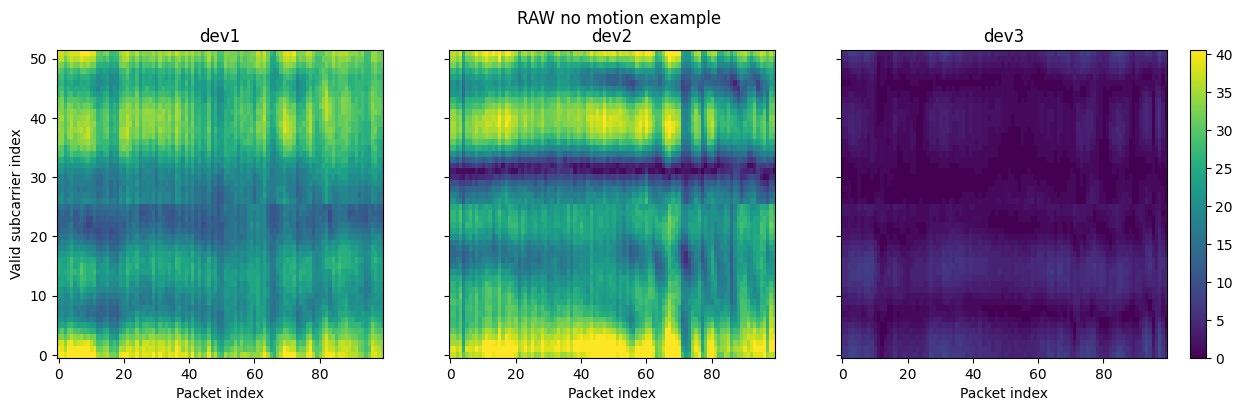

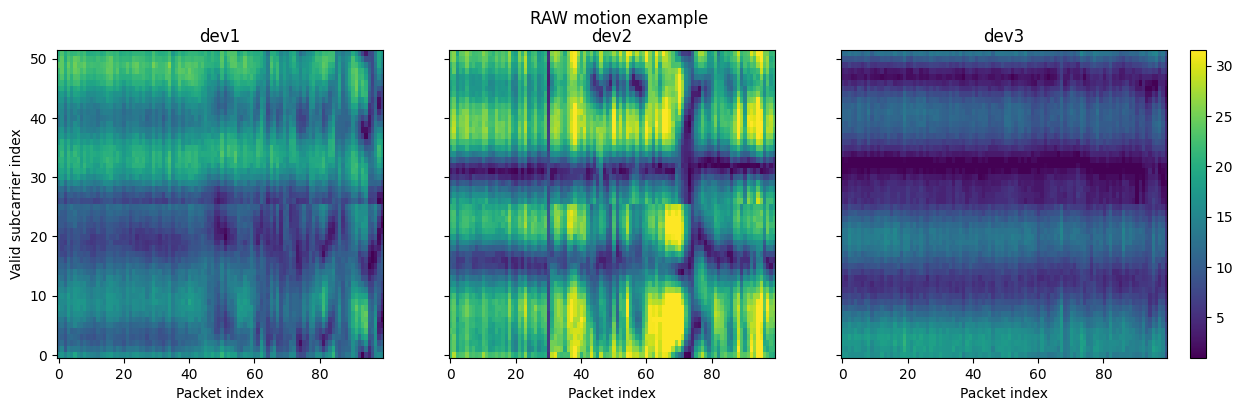

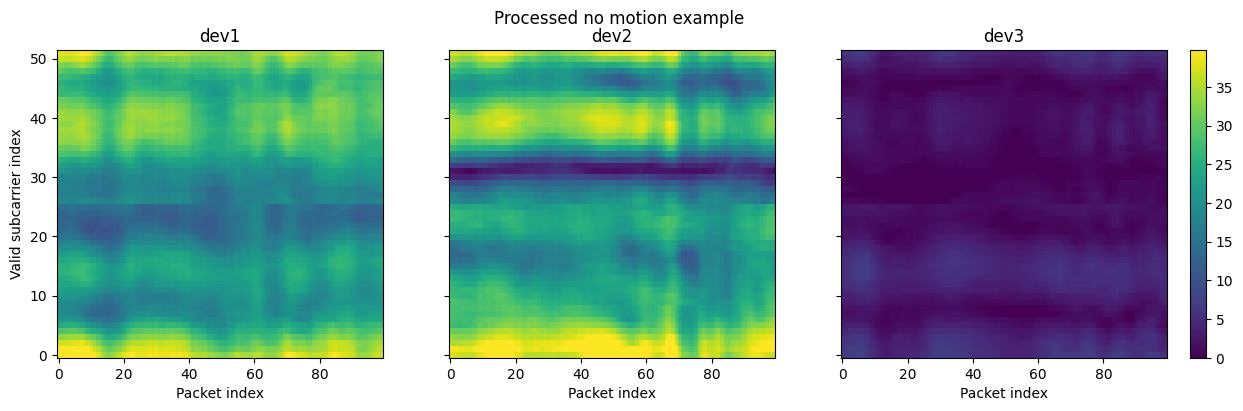

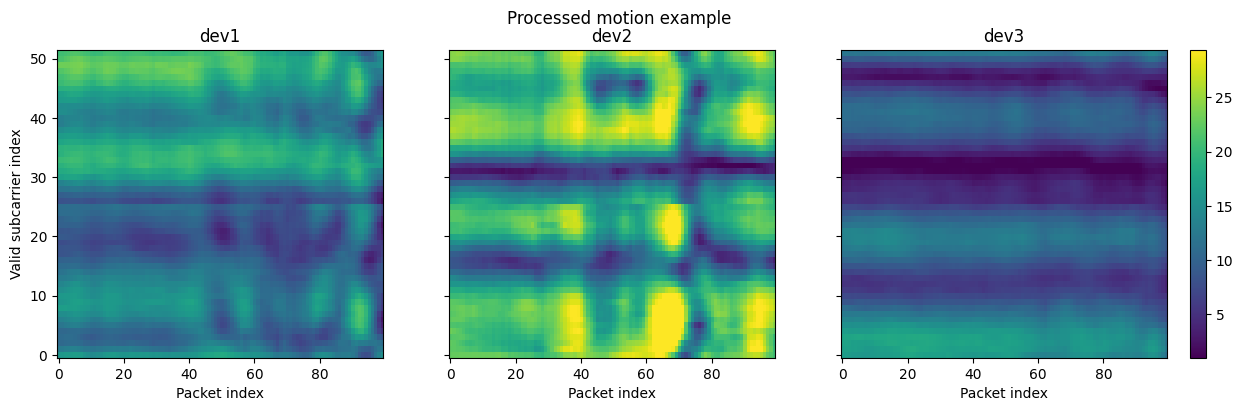

In [20]:
def robust_color_limits(X, q: float = 99.0, center_zero: bool = False):
    X = np.asarray(X, dtype=np.float32)
    finite = X[np.isfinite(X)]
    if finite.size == 0:
        return None, None

    if center_zero:
        lim = np.nanpercentile(np.abs(finite), q)
        lim = max(float(lim), 1e-6)
        return -lim, lim

    lo, hi = np.nanpercentile(finite, [100 - q, q])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        return None, None
    return float(lo), float(hi)


def plot_receiver_heatmaps(X, title: str, device_names=DEVICE_ORDER, max_packets: int = 100, center_zero: bool = False):
    """Plot [T, D, S] as one heatmap per receiver."""

    T = min(max_packets, X.shape[0])
    fig, axes = plt.subplots(1, X.shape[1], figsize=(15, 4), sharey=True)
    if X.shape[1] == 1:
        axes = [axes]

    vmin, vmax = robust_color_limits(X[:T], center_zero=center_zero)
    cmap = "coolwarm" if center_zero else "viridis"

    for dev_i, ax in enumerate(axes):
        image = ax.imshow(
            X[:T, dev_i, :].T,
            origin="lower",
            aspect="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(device_names[dev_i])
        ax.set_xlabel("Packet index")
        if dev_i == 0:
            ax.set_ylabel("Valid subcarrier index")

    fig.colorbar(image, ax=axes, fraction=0.025, pad=0.02)
    fig.suptitle(title)
    plt.show()


static_proc = preprocess_amplitude(example_static["amplitude"], PREPROCESS_CONFIG)
motion_proc = preprocess_amplitude(example_motion["amplitude"], PREPROCESS_CONFIG)

plot_receiver_heatmaps(example_static["amplitude"], "RAW no motion example")
plot_receiver_heatmaps(example_motion["amplitude"], "RAW motion example")
plot_receiver_heatmaps(static_proc["normalized"], "Processed no motion example", center_zero=PREPROCESS_CONFIG.apply_zscore)
plot_receiver_heatmaps(motion_proc["normalized"], "Processed motion example", center_zero=PREPROCESS_CONFIG.apply_zscore)

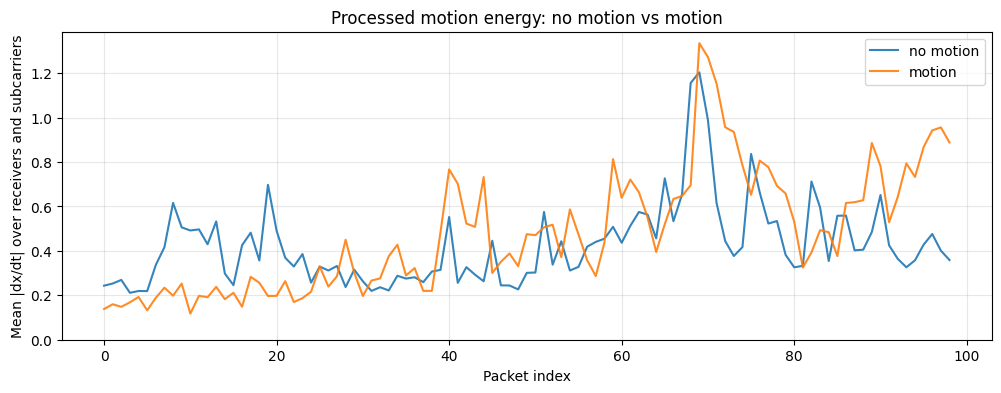

In [21]:
def plot_motion_energy_comparison(static_X: np.ndarray, motion_X: np.ndarray, title: str = "Motion energy"):
    e_static = motion_energy(static_X)
    e_motion = motion_energy(motion_X)
    ymax = np.percentile(np.r_[e_static, e_motion], 99)
    ymax = max(float(ymax) * 1.15, 1e-6)

    plt.figure(figsize=(12, 4))
    plt.plot(e_static, label="no motion", alpha=0.9)
    plt.plot(e_motion, label="motion", alpha=0.9)
    plt.title(title)
    plt.xlabel("Packet index")
    plt.ylabel("Mean |dx/dt| over receivers and subcarriers")
    plt.ylim(0, ymax)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


plot_motion_energy_comparison(
    static_proc["normalized"],
    motion_proc["normalized"],
    title="Processed motion energy: no motion vs motion",
)

## Build Binary Windows

Для текущей задачи `label_00` получает `y=0`, а `label_01/02/03` получают `y=1`. При этом `distance_m` сохраняется в metadata для будущей многоклассовой постановки.

In [22]:
def round_robin_sample_by_column(
    df: pd.DataFrame,
    column: str,
    n: int | None,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    if n is None or len(df) <= n:
        return df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    rng = np.random.default_rng(random_state)
    groups = []
    for _, group in df.groupby(column, sort=True):
        order = rng.permutation(len(group))
        groups.append(group.iloc[order].reset_index(drop=True))

    selected_rows = []
    cursors = [0] * len(groups)
    while len(selected_rows) < n:
        added = False
        for group_i, group in enumerate(groups):
            cursor = cursors[group_i]
            if cursor < len(group) and len(selected_rows) < n:
                selected_rows.append(group.iloc[cursor])
                cursors[group_i] += 1
                added = True
        if not added:
            break

    return pd.DataFrame(selected_rows).reset_index(drop=True)


def select_recordings_for_binary_task(
    recordings: pd.DataFrame,
    balance_binary_classes: bool = BALANCE_BINARY_CLASSES,
    max_per_binary_class: int | None = ML_MAX_RECORDINGS_PER_BINARY_CLASS,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    counts = recordings["binary_label"].value_counts().sort_index()
    if balance_binary_classes:
        target = int(counts.min())
    else:
        target = None

    if max_per_binary_class is not None:
        target = max_per_binary_class if target is None else min(target, max_per_binary_class)

    selected = []
    for binary_label, group in recordings.groupby("binary_label", sort=True):
        selected.append(
            round_robin_sample_by_column(
                group,
                column="source_label",
                n=target,
                random_state=random_state + int(binary_label),
            )
        )

    return pd.concat(selected, ignore_index=True).sample(frac=1.0, random_state=random_state).reset_index(drop=True)


def segment_array(X: np.ndarray, window: int = ML_WINDOW, step: int = ML_STEP) -> list[np.ndarray]:
    if len(X) < window:
        return []
    return [X[start:start + window] for start in range(0, len(X) - window + 1, step)]


def build_binary_windows(
    recordings: pd.DataFrame,
    preprocess_config: PreprocessConfig = PREPROCESS_CONFIG,
    window: int = ML_WINDOW,
    step: int = ML_STEP,
    random_state: int = RANDOM_STATE,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, pd.DataFrame, np.ndarray]:
    X_list = []
    rssi_list = []
    y_list = []
    meta_rows = []

    selected = select_recordings_for_binary_task(recordings, random_state=random_state)

    for i, row in selected.iterrows():
        try:
            rec = load_recording(row)
            proc = preprocess_amplitude(rec["amplitude"], preprocess_config)
            X_proc = proc["normalized"]
            X_segments = segment_array(X_proc, window=window, step=step)
            rssi_segments = segment_array(rec["rssi"], window=window, step=step)

            for segment_i, (x_seg, rssi_seg) in enumerate(zip(X_segments, rssi_segments)):
                X_list.append(x_seg.astype(np.float32))
                rssi_list.append(rssi_seg.astype(np.float32))
                y_list.append(rec["binary_label"])
                meta_rows.append({
                    "recording_id": rec["recording_id"],
                    "segment": segment_i,
                    "person": rec["person"],
                    "source_label": rec["source_label"],
                    "binary_label": rec["binary_label"],
                    "binary_name": "no_motion" if rec["binary_label"] == 0 else "motion",
                    "distance_m": rec["distance_m"],
                    "n_packets": x_seg.shape[0],
                    "n_devices": x_seg.shape[1],
                    "n_subcarriers": x_seg.shape[2],
                })
        except Exception as exc:
            print(f"Skip {row['recording_id']}: {exc}")

    if not X_list:
        raise ValueError("No windows were built. Check parser, window length, and dataset path.")

    X = np.stack(X_list).astype(np.float32)          # [N, T, D, S]
    rssi = np.stack(rssi_list).astype(np.float32)    # [N, T, D]
    y = np.asarray(y_list, dtype=np.int64)
    metadata = pd.DataFrame(meta_rows)
    groups = metadata[SPLIT_GROUP].astype(str).to_numpy()
    return X, y, groups, metadata, rssi


X_bin, y_bin, groups_bin, metadata_bin, rssi_bin = build_binary_windows(recordings_df)

print("X [N, T, D, S]:", X_bin.shape)
print("RSSI [N, T, D]:", rssi_bin.shape)
print("y:", y_bin.shape)
print("Binary balance [no_motion, motion]:", np.bincount(y_bin, minlength=2))
print("Groups:", SPLIT_GROUP, len(np.unique(groups_bin)))
print("\nWindows by source label:")
display(metadata_bin["source_label"].value_counts().sort_index())
print("\nWindows by person/source label:")
display(metadata_bin.groupby(["person", "source_label"]).size().unstack(fill_value=0))

X [N, T, D, S]: (800, 100, 3, 52)
RSSI [N, T, D]: (800, 100, 3)
y: (800,)
Binary balance [no_motion, motion]: [400 400]
Groups: recording_id 800

Windows by source label:


source_label
label_00    400
label_01    134
label_02    133
label_03    133
Name: count, dtype: int64


Windows by person/source label:


source_label,label_00,label_01,label_02,label_03
person,,,,
id_person_01,100,41,29,35
id_person_02,100,30,34,36
id_person_03,100,35,37,31
id_person_04,100,28,33,31


## Feature Extraction

Признаки остаются классическими табличными: статистики по окну, энергия изменений во времени, per-subcarrier энергия и per-time профиль. Информация с каждого приёмника сохраняется отдельными признаками `dev1/dev2/dev3`, плюс добавлены простые cross-device признаки.

In [23]:
def summarize_vector(v, prefix: str) -> dict[str, float]:
    v = np.asarray(v, dtype=np.float32)
    if v.size == 0:
        return {
            f"{prefix}_mean": 0.0,
            f"{prefix}_std": 0.0,
            f"{prefix}_min": 0.0,
            f"{prefix}_p10": 0.0,
            f"{prefix}_median": 0.0,
            f"{prefix}_p90": 0.0,
            f"{prefix}_max": 0.0,
        }

    return {
        f"{prefix}_mean": float(np.mean(v)),
        f"{prefix}_std": float(np.std(v)),
        f"{prefix}_min": float(np.min(v)),
        f"{prefix}_p10": float(np.percentile(v, 10)),
        f"{prefix}_median": float(np.median(v)),
        f"{prefix}_p90": float(np.percentile(v, 90)),
        f"{prefix}_max": float(np.max(v)),
    }


def add_sequence_features(feats: dict[str, float], values: np.ndarray, prefix: str) -> None:
    for i, value in enumerate(np.asarray(values, dtype=np.float32)):
        feats[f"{prefix}_{i:03d}"] = float(value)


def extract_one_window_features(window: np.ndarray, rssi_window: np.ndarray, device_names=DEVICE_ORDER) -> dict[str, float]:
    """Extract features from one [T, D, S] CSI window."""

    feats = {}
    d_time = np.diff(window, axis=0)
    abs_d_time = np.abs(d_time)
    abs_window = np.abs(window)
    global_motion_e = np.mean(abs_d_time, axis=(1, 2))

    feats.update(summarize_vector(window.ravel(), "absolute__global_x"))
    feats.update(summarize_vector(abs_window.ravel(), "absolute__global_abs_x"))
    feats.update(summarize_vector(d_time.ravel(), "motion__global_dt"))
    feats.update(summarize_vector(abs_d_time.ravel(), "motion__global_abs_dt"))
    feats.update(summarize_vector(global_motion_e, "motion__global_motion_energy"))

    receiver_spread = np.std(window, axis=1)  # [T, S], spread across dev1/dev2/dev3
    feats.update(summarize_vector(receiver_spread.ravel(), "absolute__receiver_spread"))

    for dev_i, dev in enumerate(device_names):
        W = window[:, dev_i, :]
        dW = np.diff(W, axis=0)
        abs_dW = np.abs(dW)
        e_t = np.mean(abs_dW, axis=1)

        feats.update(summarize_vector(W.ravel(), f"absolute__{dev}_x"))
        feats.update(summarize_vector(np.abs(W).ravel(), f"absolute__{dev}_abs_x"))
        feats.update(summarize_vector(dW.ravel(), f"motion__{dev}_dt"))
        feats.update(summarize_vector(abs_dW.ravel(), f"motion__{dev}_abs_dt"))
        feats.update(summarize_vector(e_t, f"motion__{dev}_motion_energy"))

        add_sequence_features(feats, np.mean(W, axis=0), f"absolute__{dev}_sc_mean")
        add_sequence_features(feats, np.std(W, axis=0), f"absolute__{dev}_sc_std")
        add_sequence_features(feats, np.mean(abs_dW, axis=0), f"motion__{dev}_sc_energy")
        add_sequence_features(feats, np.mean(W, axis=1), f"absolute__{dev}_t_mean")
        add_sequence_features(feats, np.r_[e_t, e_t[-1] if len(e_t) else 0.0], f"motion__{dev}_t_energy")

        rssi = rssi_window[:, dev_i]
        rssi_dt = np.diff(rssi)
        feats.update(summarize_vector(rssi, f"absolute__{dev}_rssi"))
        feats.update(summarize_vector(rssi_dt, f"motion__{dev}_rssi_dt"))

    for left_i in range(len(device_names)):
        for right_i in range(left_i + 1, len(device_names)):
            left = device_names[left_i]
            right = device_names[right_i]
            pair_absdiff = np.abs(window[:, left_i, :] - window[:, right_i, :])
            pair_absdiff_dt = np.abs(np.diff(pair_absdiff, axis=0))
            feats.update(summarize_vector(pair_absdiff.ravel(), f"absolute__pair_{left}_{right}_absdiff"))
            feats.update(summarize_vector(pair_absdiff_dt.ravel(), f"motion__pair_{left}_{right}_absdiff_dt"))

    return feats


def extract_csi_features(X: np.ndarray, rssi: np.ndarray) -> pd.DataFrame:
    rows = [extract_one_window_features(window, rssi_window) for window, rssi_window in zip(X, rssi)]
    return pd.DataFrame(rows).astype(np.float32)


def select_feature_columns(features: pd.DataFrame, feature_set: str = FEATURE_SET) -> list[str]:
    if feature_set == "all":
        return list(features.columns)
    if feature_set == "motion_only":
        cols = [c for c in features.columns if c.startswith("motion__")]
    elif feature_set == "absolute_only":
        cols = [c for c in features.columns if c.startswith("absolute__")]
    else:
        raise ValueError("Unknown FEATURE_SET. Use 'motion_only', 'absolute_only', or 'all'.")

    if not cols:
        raise ValueError(f"FEATURE_SET={feature_set!r} selected zero columns.")
    return cols


features_all = extract_csi_features(X_bin, rssi_bin)
selected_feature_columns = select_feature_columns(features_all, FEATURE_SET)
features_ml = features_all[selected_feature_columns]

print("Feature table, all:", features_all.shape)
print(f"FEATURE_SET = {FEATURE_SET!r}")
print("Feature table, selected:", features_ml.shape)
display(features_ml.head())

Feature table, all: (800, 1299)
FEATURE_SET = 'motion_only'
Feature table, selected: (800, 582)


,motion__global_dt_mean,motion__global_dt_std,motion__global_dt_min,motion__global_dt_p10,motion__global_dt_median,motion__global_dt_p90,motion__global_dt_max,motion__global_abs_dt_mean,motion__global_abs_dt_std,motion__global_abs_dt_min,...,motion__pair_dev1_dev3_absdiff_dt_median,motion__pair_dev1_dev3_absdiff_dt_p90,motion__pair_dev1_dev3_absdiff_dt_max,motion__pair_dev2_dev3_absdiff_dt_mean,motion__pair_dev2_dev3_absdiff_dt_std,motion__pair_dev2_dev3_absdiff_dt_min,motion__pair_dev2_dev3_absdiff_dt_p10,motion__pair_dev2_dev3_absdiff_dt_median,motion__pair_dev2_dev3_absdiff_dt_p90,motion__pair_dev2_dev3_absdiff_dt_max
0,0.061042,1.182480,-7.541443,-1.055628,0.027632,1.239600,8.516197,0.720414,0.939674,0.0,...,0.431198,1.590282,5.070750,1.348326,1.244500,0.001179,0.187189,1.001431,2.986656,8.644417
1,0.003007,1.151114,-10.253109,-0.979807,-0.011092,0.973621,9.887362,0.678351,0.930007,0.0,...,0.486108,1.342577,4.013434,1.272263,1.418765,0.000217,0.142579,0.841605,2.832748,11.145172
2,0.003178,0.360381,-1.845692,-0.446913,0.000000,0.442761,1.705904,0.247764,0.261720,0.0,...,0.304814,0.776928,1.817511,0.333343,0.256266,0.000056,0.052081,0.281481,0.693036,1.569872
3,-0.003564,1.044342,-5.775900,-1.253821,-0.006592,1.254325,5.142830,0.769037,0.706573,0.0,...,0.769346,2.108407,5.215014,1.149724,0.987252,0.001150,0.155399,0.904165,2.445531,6.875583
4,-0.005594,0.252128,-1.466377,-0.307076,0.000000,0.287425,1.389629,0.176964,0.179676,0.0,...,0.231882,0.583747,1.262060,0.205221,0.164681,0.000041,0.030956,0.169436,0.425714,1.343554


## Train/Test Split

Split делается группами. По умолчанию группа равна `recording_id`, поэтому окна одной и той же папки `test_*` не попадают одновременно в train и test.

In [24]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(features_ml, y_bin, groups=groups_bin))

X_train = features_ml.iloc[train_idx]
X_test = features_ml.iloc[test_idx]
y_train = y_bin[train_idx]
y_test = y_bin[test_idx]
meta_train = metadata_bin.iloc[train_idx].reset_index(drop=True)
meta_test = metadata_bin.iloc[test_idx].reset_index(drop=True)

groups_train = groups_bin[train_idx]
groups_test = groups_bin[test_idx]

print("Train windows:", X_train.shape[0], "Test windows:", X_test.shape[0])
print("Train groups:", len(np.unique(groups_train)), "Test groups:", len(np.unique(groups_test)))
print("Train balance [no_motion, motion]:", np.bincount(y_train, minlength=2))
print("Test balance  [no_motion, motion]:", np.bincount(y_test, minlength=2))
print("\nTest labels:")
display(meta_test["source_label"].value_counts().sort_index())
print("\nTest persons:")
display(meta_test["person"].value_counts().sort_index())

Train windows: 560 Test windows: 240
Train groups: 560 Test groups: 240
Train balance [no_motion, motion]: [283 277]
Test balance  [no_motion, motion]: [117 123]

Test labels:


source_label
label_00    117
label_01     47
label_02     38
label_03     38
Name: count, dtype: int64


Test persons:


person
id_person_01    63
id_person_02    62
id_person_03    53
id_person_04    62
Name: count, dtype: int64

In [25]:
models = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "logreg_balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=RANDOM_STATE,
        )),
    ]),
    "random_forest_balanced": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "svm_rbf_balanced": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE,
        )),
    ]),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    print("fit:", name)

fit: dummy_most_frequent
fit: logreg_balanced
fit: random_forest_balanced
fit: svm_rbf_balanced


In [26]:
def predict_positive_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        score = model.decision_function(X)
        return (score - score.min()) / (score.max() - score.min() + 1e-8)
    return None


def evaluate_model(name: str, model, X_test: pd.DataFrame, y_test: np.ndarray) -> dict[str, float | str]:
    y_pred = model.predict(X_test)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=[0, 1],
        zero_division=0,
    )
    score = predict_positive_score(model, X_test)
    auc = np.nan
    if score is not None and len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, score)

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_no_motion": precision[0],
        "recall_no_motion": recall[0],
        "f1_no_motion": f1[0],
        "precision_motion": precision[1],
        "recall_motion": recall[1],
        "f1_motion": f1[1],
        "roc_auc": auc,
        "support_no_motion": support[0],
        "support_motion": support[1],
    }


metrics_df = pd.DataFrame([
    evaluate_model(name, model, X_test, y_test)
    for name, model in fitted_models.items()
]).sort_values("balanced_accuracy", ascending=False)

display(metrics_df)

,model,accuracy,balanced_accuracy,precision_no_motion,recall_no_motion,f1_no_motion,precision_motion,recall_motion,f1_motion,roc_auc,support_no_motion,support_motion
1,logreg_balanced,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,117,123
3,svm_rbf_balanced,0.991667,0.991661,0.991453,0.991453,0.991453,0.991870,0.99187,0.991870,0.999931,117,123
2,random_forest_balanced,0.987500,0.987596,0.983051,0.991453,0.987234,0.991803,0.98374,0.987755,0.998958,117,123
0,dummy_most_frequent,0.487500,0.500000,0.487500,1.000000,0.655462,0.000000,0.00000,0.000000,0.500000,117,123


Best model: logreg_balanced
              precision    recall  f1-score   support

   no_motion       1.00      1.00      1.00       117
      motion       1.00      1.00      1.00       123

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



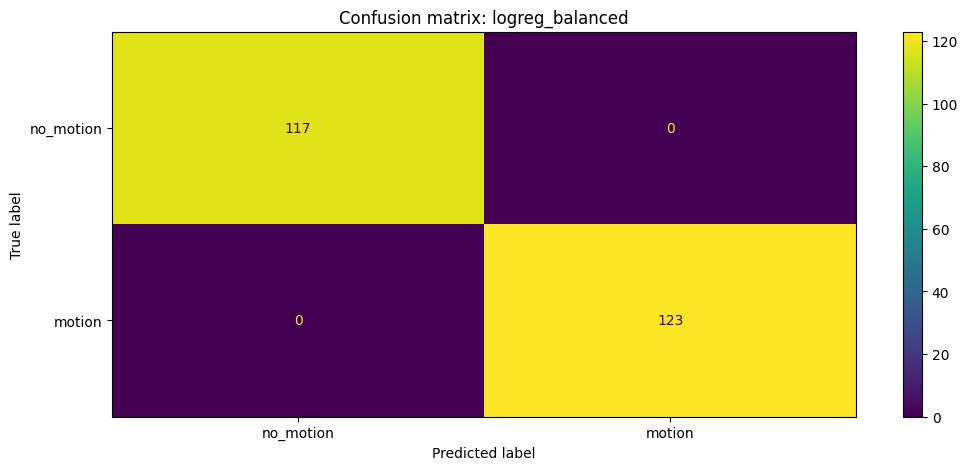

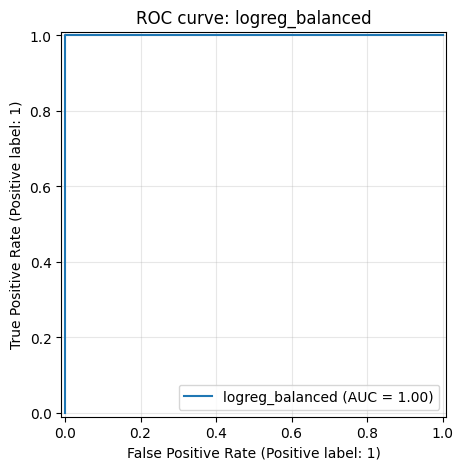

In [27]:
BEST_MODEL_NAME = metrics_df.iloc[0]["model"]
best_model = fitted_models[BEST_MODEL_NAME]
y_pred = best_model.predict(X_test)

print("Best model:", BEST_MODEL_NAME)
print(classification_report(
    y_test,
    y_pred,
    target_names=["no_motion", "motion"],
    zero_division=0,
))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=["no_motion", "motion"]).plot(values_format="d")
plt.title(f"Confusion matrix: {BEST_MODEL_NAME}")
plt.grid(False)
plt.show()

score = predict_positive_score(best_model, X_test)
if score is not None and len(np.unique(y_test)) == 2:
    RocCurveDisplay.from_predictions(y_test, score, name=BEST_MODEL_NAME)
    plt.title(f"ROC curve: {BEST_MODEL_NAME}")
    plt.grid(alpha=0.3)
    plt.show()

,feature,importance
382,motion__dev3_dt_std,0.046734
391,motion__dev3_abs_dt_p10,0.043695
389,motion__dev3_abs_dt_std,0.037275
432,motion__dev3_sc_energy_030,0.032368
388,motion__dev3_abs_dt_mean,0.028512
394,motion__dev3_abs_dt_max,0.027417
449,motion__dev3_sc_energy_047,0.027242
448,motion__dev3_sc_energy_046,0.026824
409,motion__dev3_sc_energy_007,0.024754
400,motion__dev3_motion_energy_p90,0.024249


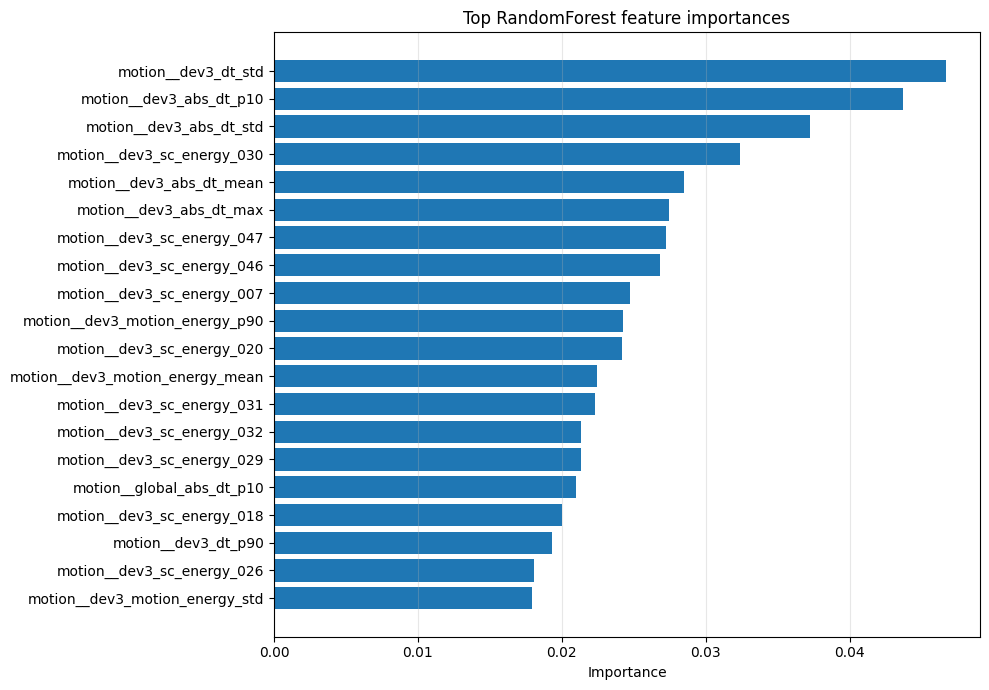

In [28]:
rf = fitted_models.get("random_forest_balanced")
if rf is not None and hasattr(rf, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": features_ml.columns,
        "importance": rf.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(importance_df.head(30))

    top = importance_df.head(20).iloc[::-1]
    plt.figure(figsize=(10, 7))
    plt.barh(top["feature"], top["importance"])
    plt.title("Top RandomForest feature importances")
    plt.xlabel("Importance")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Device Scale Diagnostics

Этот блок проверяет, не становится ли задача слишком лёгкой из-за различий масштаба между приёмниками. Особенно полезно смотреть `dev3`: если у него одновременно другой RSSI, другой amplitude level и большая разница `motion/no_motion`, модель может использовать это как shortcut.

,binary_label,binary_name,device,amp_mean,amp_std,amp_p10,amp_p90,abs_dt_mean,abs_dt_p90,rssi_mean,rssi_std
0,0,no_motion,dev1,23.271,6.325,15.348,31.733,0.502,1.096,-44.470,1.219
1,0,no_motion,dev2,19.779,7.743,9.713,29.971,0.541,1.215,-45.291,1.528
2,0,no_motion,dev3,2.367,1.599,0.540,4.539,0.123,0.283,-61.258,2.057
3,1,motion,dev1,16.650,6.259,9.112,24.853,0.643,1.409,-46.650,2.274
4,1,motion,dev2,23.522,11.855,9.622,38.777,0.992,2.178,-44.162,2.837
5,1,motion,dev3,6.377,4.086,1.751,12.497,0.336,0.755,-54.209,3.468



amp_mean


binary_name,motion,no_motion,motion_over_no_motion
device,,,
dev1,16.650,23.271,0.716
dev2,23.522,19.779,1.189
dev3,6.377,2.367,2.694



abs_dt_mean


binary_name,motion,no_motion,motion_over_no_motion
device,,,
dev1,0.643,0.502,1.282
dev2,0.992,0.541,1.834
dev3,0.336,0.123,2.736



rssi_mean


binary_name,motion,no_motion,motion_minus_no_motion
device,,,
dev1,-46.650,-44.470,-2.180
dev2,-44.162,-45.291,1.129
dev3,-54.209,-61.258,7.049


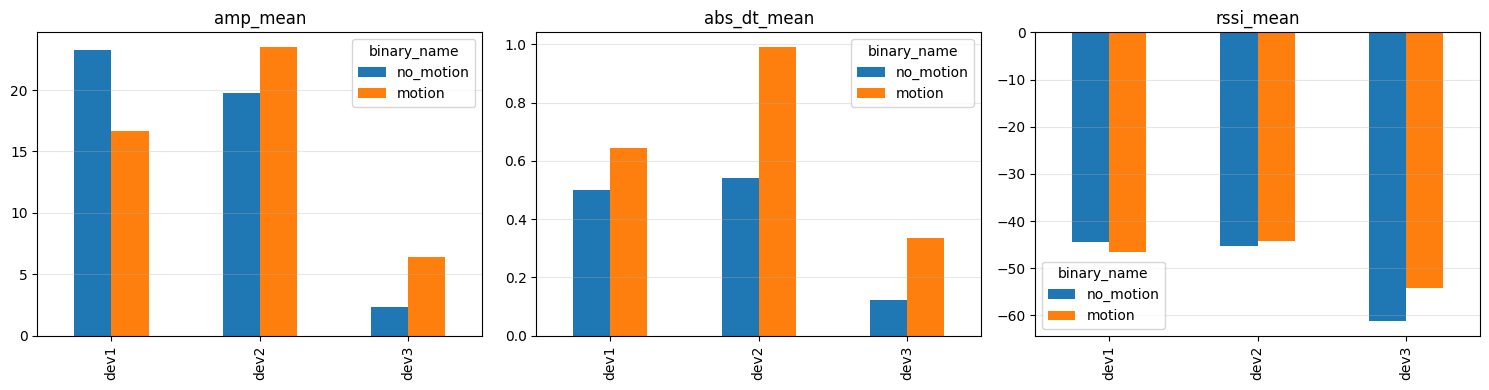

In [29]:
def summarize_device_scale(X: np.ndarray, rssi: np.ndarray, y: np.ndarray, device_names=DEVICE_ORDER) -> pd.DataFrame:
    rows = []
    for label_value, label_name in [(0, "no_motion"), (1, "motion")]:
        mask = y == label_value
        for dev_i, dev in enumerate(device_names):
            Xi = X[mask, :, dev_i, :]
            Ri = rssi[mask, :, dev_i]
            abs_dt = np.abs(np.diff(Xi, axis=1))
            rows.append({
                "binary_label": label_value,
                "binary_name": label_name,
                "device": dev,
                "amp_mean": float(np.mean(Xi)),
                "amp_std": float(np.std(Xi)),
                "amp_p10": float(np.percentile(Xi, 10)),
                "amp_p90": float(np.percentile(Xi, 90)),
                "abs_dt_mean": float(np.mean(abs_dt)),
                "abs_dt_p90": float(np.percentile(abs_dt, 90)),
                "rssi_mean": float(np.mean(Ri)),
                "rssi_std": float(np.std(Ri)),
            })
    return pd.DataFrame(rows)


device_scale_df = summarize_device_scale(X_bin, rssi_bin, y_bin)
display(device_scale_df.round(3))

for metric in ["amp_mean", "abs_dt_mean", "rssi_mean"]:
    pivot = device_scale_df.pivot(index="device", columns="binary_name", values=metric)
    if {"motion", "no_motion"}.issubset(pivot.columns):
        if metric == "rssi_mean":
            pivot["motion_minus_no_motion"] = pivot["motion"] - pivot["no_motion"]
        else:
            pivot["motion_over_no_motion"] = pivot["motion"] / pivot["no_motion"].replace(0, np.nan)
    print(f"\n{metric}")
    display(pivot.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["amp_mean", "abs_dt_mean", "rssi_mean"]):
    pivot = device_scale_df.pivot(index="device", columns="binary_name", values=metric)
    pivot[["no_motion", "motion"]].plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.3)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Robustness Diagnostics

Здесь сравниваются preprocessing-варианты и feature subsets. Основные вопросы:

- остаются ли метрики высокими после per-record z-score;
- насколько результат зависит от `dev3`;
- насколько падает качество при split по человеку;
- есть ли человек, на котором leave-one-person-out проседает.

In [30]:
RUN_ROBUSTNESS_DIAGNOSTICS = True

# Set an integer, for example 80, if you want a faster diagnostic run.
# None means the same balanced size as the main binary experiment.
DIAG_MAX_RECORDINGS_PER_BINARY_CLASS = None

DIAG_PREPROCESS_CONFIGS = {
    "smooth_raw_scale": PreprocessConfig(
        pipeline="hampel_savgol",
        apply_detrend=False,
        apply_zscore=False,
        hampel_window=PREPROCESS_CONFIG.hampel_window,
        hampel_sigma=PREPROCESS_CONFIG.hampel_sigma,
        sg_window=PREPROCESS_CONFIG.sg_window,
        sg_poly=PREPROCESS_CONFIG.sg_poly,
        detrend_window=PREPROCESS_CONFIG.detrend_window,
        scale_floor_percentile=PREPROCESS_CONFIG.scale_floor_percentile,
        z_clip=PREPROCESS_CONFIG.z_clip,
    ),
    "smooth_zscore": PreprocessConfig(
        pipeline="hampel_savgol",
        apply_detrend=False,
        apply_zscore=True,
        hampel_window=PREPROCESS_CONFIG.hampel_window,
        hampel_sigma=PREPROCESS_CONFIG.hampel_sigma,
        sg_window=PREPROCESS_CONFIG.sg_window,
        sg_poly=PREPROCESS_CONFIG.sg_poly,
        detrend_window=PREPROCESS_CONFIG.detrend_window,
        scale_floor_percentile=PREPROCESS_CONFIG.scale_floor_percentile,
        z_clip=PREPROCESS_CONFIG.z_clip,
    ),
    "smooth_detrend_zscore": PreprocessConfig(
        pipeline="hampel_savgol",
        apply_detrend=True,
        apply_zscore=True,
        hampel_window=PREPROCESS_CONFIG.hampel_window,
        hampel_sigma=PREPROCESS_CONFIG.hampel_sigma,
        sg_window=PREPROCESS_CONFIG.sg_window,
        sg_poly=PREPROCESS_CONFIG.sg_poly,
        detrend_window=PREPROCESS_CONFIG.detrend_window,
        scale_floor_percentile=PREPROCESS_CONFIG.scale_floor_percentile,
        z_clip=PREPROCESS_CONFIG.z_clip,
    ),
    "median_detrend_zscore": PreprocessConfig(
        pipeline="median",
        apply_detrend=True,
        apply_zscore=True,
        median_window=PREPROCESS_CONFIG.median_window,
        detrend_window=PREPROCESS_CONFIG.detrend_window,
        scale_floor_percentile=PREPROCESS_CONFIG.scale_floor_percentile,
        z_clip=PREPROCESS_CONFIG.z_clip,
    ),
}


def make_logreg_model() -> Pipeline:
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=RANDOM_STATE,
        )),
    ])


def build_raw_windows_for_diagnostics(
    recordings: pd.DataFrame,
    window: int = ML_WINDOW,
    step: int = ML_STEP,
    max_per_binary_class: int | None = DIAG_MAX_RECORDINGS_PER_BINARY_CLASS,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
    selected = select_recordings_for_binary_task(
        recordings,
        balance_binary_classes=True,
        max_per_binary_class=max_per_binary_class,
        random_state=RANDOM_STATE,
    )

    X_list = []
    rssi_list = []
    y_list = []
    meta_rows = []

    for _, row in selected.iterrows():
        rec = load_recording(row)
        X_segments = segment_array(rec["amplitude"], window=window, step=step)
        rssi_segments = segment_array(rec["rssi"], window=window, step=step)
        for segment_i, (x_seg, rssi_seg) in enumerate(zip(X_segments, rssi_segments)):
            X_list.append(x_seg.astype(np.float32))
            rssi_list.append(rssi_seg.astype(np.float32))
            y_list.append(rec["binary_label"])
            meta_rows.append({
                "recording_id": rec["recording_id"],
                "segment": segment_i,
                "person": rec["person"],
                "source_label": rec["source_label"],
                "binary_label": rec["binary_label"],
                "binary_name": "no_motion" if rec["binary_label"] == 0 else "motion",
                "distance_m": rec["distance_m"],
            })

    return (
        np.stack(X_list).astype(np.float32),
        np.stack(rssi_list).astype(np.float32),
        np.asarray(y_list, dtype=np.int64),
        pd.DataFrame(meta_rows),
    )


def preprocess_window_batch(X_raw: np.ndarray, config: PreprocessConfig) -> np.ndarray:
    return np.stack([
        preprocess_amplitude(window, config)["normalized"].astype(np.float32)
        for window in X_raw
    ])


def feature_subset_columns(columns: list[str]) -> dict[str, list[str]]:
    return {
        "all_selected": columns,
        "without_dev3": [c for c in columns if "dev3" not in c],
        "dev1_only": [c for c in columns if "motion__dev1_" in c],
        "dev2_only": [c for c in columns if "motion__dev2_" in c],
        "dev3_only": [c for c in columns if "motion__dev3_" in c],
        "global_only": [c for c in columns if c.startswith("motion__global")],
        "pairs_only": [c for c in columns if c.startswith("motion__pair_")],
    }


def evaluate_split_once(
    features: pd.DataFrame,
    y: np.ndarray,
    groups: np.ndarray,
    split_name: str,
    feature_subset: str,
    config_name: str,
) -> dict[str, object]:
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
    train_idx, test_idx = next(splitter.split(features, y, groups=groups))

    model = make_logreg_model()
    model.fit(features.iloc[train_idx], y[train_idx])
    y_pred = model.predict(features.iloc[test_idx])
    score = model.predict_proba(features.iloc[test_idx])[:, 1]

    auc = np.nan
    if len(np.unique(y[test_idx])) == 2:
        auc = roc_auc_score(y[test_idx], score)

    return {
        "config": config_name,
        "split": split_name,
        "feature_subset": feature_subset,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "accuracy": accuracy_score(y[test_idx], y_pred),
        "balanced_accuracy": balanced_accuracy_score(y[test_idx], y_pred),
        "roc_auc": auc,
        "support_no_motion": int(np.sum(y[test_idx] == 0)),
        "support_motion": int(np.sum(y[test_idx] == 1)),
    }


def evaluate_leave_one_person_out(
    features: pd.DataFrame,
    y: np.ndarray,
    persons: np.ndarray,
    config_name: str,
    feature_subset: str,
) -> pd.DataFrame:
    rows = []
    for held_out_person in sorted(np.unique(persons)):
        test_idx = np.flatnonzero(persons == held_out_person)
        train_idx = np.flatnonzero(persons != held_out_person)

        model = make_logreg_model()
        model.fit(features.iloc[train_idx], y[train_idx])
        y_pred = model.predict(features.iloc[test_idx])
        score = model.predict_proba(features.iloc[test_idx])[:, 1]
        auc = np.nan
        if len(np.unique(y[test_idx])) == 2:
            auc = roc_auc_score(y[test_idx], score)

        rows.append({
            "config": config_name,
            "feature_subset": feature_subset,
            "held_out_person": held_out_person,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "accuracy": accuracy_score(y[test_idx], y_pred),
            "balanced_accuracy": balanced_accuracy_score(y[test_idx], y_pred),
            "roc_auc": auc,
            "support_no_motion": int(np.sum(y[test_idx] == 0)),
            "support_motion": int(np.sum(y[test_idx] == 1)),
        })
    return pd.DataFrame(rows)


def rf_importance_mass(features: pd.DataFrame, y: np.ndarray, groups: np.ndarray, config_name: str) -> pd.DataFrame:
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
    train_idx, _ = next(splitter.split(features, y, groups=groups))
    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_model.fit(features.iloc[train_idx], y[train_idx])
    importance = pd.Series(rf_model.feature_importances_, index=features.columns)
    groups_map = {
        "global": [c for c in features.columns if c.startswith("motion__global")],
        "dev1": [c for c in features.columns if "motion__dev1_" in c],
        "dev2": [c for c in features.columns if "motion__dev2_" in c],
        "dev3": [c for c in features.columns if "motion__dev3_" in c],
        "pairs_with_dev3": [c for c in features.columns if "pair_dev1_dev3" in c or "pair_dev2_dev3" in c],
        "pair_dev1_dev2": [c for c in features.columns if "pair_dev1_dev2" in c],
    }
    rows = [
        {"config": config_name, "feature_group": name, "importance_mass": float(importance[cols].sum())}
        for name, cols in groups_map.items()
    ]
    return pd.DataFrame(rows)


if RUN_ROBUSTNESS_DIAGNOSTICS:
    X_diag_raw, rssi_diag, y_diag, meta_diag = build_raw_windows_for_diagnostics(recordings_df)
    print("Diagnostic raw X:", X_diag_raw.shape)
    print("Diagnostic balance [no_motion, motion]:", np.bincount(y_diag, minlength=2))

    diagnostic_metric_rows = []
    diagnostic_lopo_rows = []
    diagnostic_rf_rows = []

    for config_name, config in DIAG_PREPROCESS_CONFIGS.items():
        print("\nconfig:", config_name, config)
        X_diag = preprocess_window_batch(X_diag_raw, config)
        features_diag_all = extract_csi_features(X_diag, rssi_diag)
        selected_cols = select_feature_columns(features_diag_all, FEATURE_SET)
        features_diag = features_diag_all[selected_cols]
        subsets = feature_subset_columns(list(features_diag.columns))

        for subset_name, subset_cols in subsets.items():
            if not subset_cols:
                continue
            subset_features = features_diag[subset_cols]
            diagnostic_metric_rows.append(evaluate_split_once(
                subset_features,
                y_diag,
                meta_diag["recording_id"].astype(str).to_numpy(),
                split_name="recording_id",
                feature_subset=subset_name,
                config_name=config_name,
            ))
            diagnostic_metric_rows.append(evaluate_split_once(
                subset_features,
                y_diag,
                meta_diag["person"].astype(str).to_numpy(),
                split_name="person",
                feature_subset=subset_name,
                config_name=config_name,
            ))

        diagnostic_lopo_rows.append(evaluate_leave_one_person_out(
            features_diag,
            y_diag,
            meta_diag["person"].astype(str).to_numpy(),
            config_name=config_name,
            feature_subset="all_selected",
        ))
        diagnostic_rf_rows.append(rf_importance_mass(
            features_diag,
            y_diag,
            meta_diag["recording_id"].astype(str).to_numpy(),
            config_name=config_name,
        ))

    diagnostic_metrics_df = pd.DataFrame(diagnostic_metric_rows)
    diagnostic_lopo_df = pd.concat(diagnostic_lopo_rows, ignore_index=True)
    diagnostic_rf_importance_df = pd.concat(diagnostic_rf_rows, ignore_index=True)

    print("\nBalanced accuracy by config / split / feature subset")
    display(diagnostic_metrics_df.pivot_table(
        index=["config", "feature_subset"],
        columns="split",
        values="balanced_accuracy",
    ).round(4))

    print("\nLeave-one-person-out balanced accuracy")
    display(diagnostic_lopo_df.pivot_table(
        index="held_out_person",
        columns="config",
        values="balanced_accuracy",
    ).round(4))

    print("\nRandomForest importance mass by feature group")
    display(diagnostic_rf_importance_df.pivot_table(
        index="feature_group",
        columns="config",
        values="importance_mass",
    ).round(4))
else:
    print("Robustness diagnostics are disabled.")

Diagnostic raw X: (800, 100, 3, 52)
Diagnostic balance [no_motion, motion]: [400 400]

config: smooth_raw_scale PreprocessConfig(pipeline='hampel_savgol', apply_detrend=False, apply_zscore=False, hampel_window=7, hampel_sigma=3.0, sg_window=11, sg_poly=3, median_window=7, detrend_window=51, scale_floor_percentile=10.0, z_clip=8.0)

config: smooth_zscore PreprocessConfig(pipeline='hampel_savgol', apply_detrend=False, apply_zscore=True, hampel_window=7, hampel_sigma=3.0, sg_window=11, sg_poly=3, median_window=7, detrend_window=51, scale_floor_percentile=10.0, z_clip=8.0)

config: smooth_detrend_zscore PreprocessConfig(pipeline='hampel_savgol', apply_detrend=True, apply_zscore=True, hampel_window=7, hampel_sigma=3.0, sg_window=11, sg_poly=3, median_window=7, detrend_window=51, scale_floor_percentile=10.0, z_clip=8.0)

config: median_detrend_zscore PreprocessConfig(pipeline='median', apply_detrend=True, apply_zscore=True, hampel_window=7, hampel_sigma=3.0, sg_window=11, sg_poly=3, median_w

split                                 person  recording_id
config                feature_subset                      
median_detrend_zscore all_selected    0.9274        0.9750
                      dev1_only       0.7710        0.8489
                      dev2_only       0.7711        0.8424
                      dev3_only       0.9171        0.9748
                      global_only     0.9044        0.9534
                      pairs_only      0.9221        0.9790
                      without_dev3    0.9121        0.9414
smooth_detrend_zscore all_selected    0.9117        0.9547
                      dev1_only       0.7249        0.8117
                      dev2_only       0.8125        0.8420
                      dev3_only       0.8831        0.9420
                      global_only     0.9067        0.9540
                      pairs_only      0.7483        0.7466
                      without_dev3    0.8757        0.9339
smooth_raw_scale      all_selected    0.8984        1.0000
                      dev1_only       0.8715        0.8875
                      dev2_only       0.9097        0.9296
                      dev3_only       0.9115        0.9831
                      global_only     0.9714        0.9673
                      pairs_only      0.9667        0.9341
                      without_dev3    0.9351        0.9630
smooth_zscore         all_selected    0.9195        0.9504
                      dev1_only       0.7138        0.7881
                      dev2_only       0.7998        0.8334
                      dev3_only       0.8909        0.9453
                      global_only     0.9220        0.9455
                      pairs_only      0.7257        0.7226
                      without_dev3    0.8812        0.9091


Leave-one-person-out balanced accuracy


config,median_detrend_zscore,smooth_detrend_zscore,smooth_raw_scale,smooth_zscore
held_out_person,,,,
id_person_01,0.9752,0.9552,0.9852,0.9355
id_person_02,0.9900,0.9850,0.9950,0.9800
id_person_03,0.9851,0.9413,0.9950,0.9310
id_person_04,0.9189,0.9637,0.7880,0.9252



RandomForest importance mass by feature group


config,median_detrend_zscore,smooth_detrend_zscore,smooth_raw_scale,smooth_zscore
feature_group,,,,
dev1,0.1170,0.1459,0.0121,0.1558
dev2,0.1182,0.1648,0.0633,0.1825
dev3,0.4839,0.5567,0.8352,0.5480
global,0.1316,0.0855,0.0669,0.0830
pair_dev1_dev2,0.0104,0.0296,0.0001,0.0123
pairs_with_dev3,0.1389,0.0174,0.0224,0.0183


## Future Distance Classification

Для перехода к задаче расстояния не нужно менять загрузчик данных: `metadata_bin['distance_m']` уже содержит `0, 1, 2, 3`. Для постановки "если движение было, на каком расстоянии" достаточно отфильтровать `distance_m > 0`, взять `y_distance = distance_m`, сохранить групповой split и переиспользовать те же окна/признаки.